In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from scipy.optimize import curve_fit
import random

q_e=-1.6e-19
q_i=-q_e
m_e=9.11e-31

ng=256  #number of grid points on x axis
ne=200000   #number of electrons
ni=ne

t=0
epsi=8.85e-12
k_B= 1.38e-23
T_e= 5000
mode = 1
target_klD = 0.45

v_th = np.sqrt(k_B*T_e/m_e)
L_x = (2*np.pi*mode*v_th/target_klD)**2 * m_e*epsi/(ne*q_e**2)

w_p_theory = np.sqrt(ne*q_e**2/(L_x*m_e*epsi))
lambda_D   = v_th / w_p_theory
dx = L_x/ng
k_wave = 2*np.pi*mode/L_x

dt_plasma  = 0.1 / w_p_theory
dt_spatial = 0.5 * dx / v_th
dt = min(dt_plasma, dt_spatial)
t_tot = 20.0 / w_p_theory

In [17]:
v_x_his=[]
v_y_his=[]
x_his=[]
y_his=[]
phi_his=[]
E_mode_amp = []
time_steps=[]
Ek_complex = []

In [18]:
x_e=np.linspace(0,L_x,ne, endpoint=False)         #position of each electron is x[i]
x_i=np.linspace(0,L_x,ni, endpoint=False)         #position of each ion is x[i]

perturbation_amp = 1
x_e = (x_e + perturbation_amp * dx * np.cos(k_wave * x_e)) % L_x

In [19]:
print("omega_p =", w_p_theory)
print("lambda_D =", lambda_D)
print("L_x =", L_x)
print("dx =", dx)
print("dx/lambda_D =", dx/lambda_D)
print("klambda_D =", k_wave*lambda_D)

omega_p = 165.26298845121323
lambda_D = 1665.2895433286524
L_x = 23251.8284240942
dx = 90.82745478161797
dx/lambda_D = 0.05454153912482279
klambda_D = 0.45000000000000007


In [20]:
def set_rho(x_e, x_i):
    j_e= (x_e // dx).astype(int) % ng
    w_right_e = (x_e - j_e * dx) / dx
    w_left_e= 1.0 - w_right_e

    j_i= (x_i // dx).astype(int) % ng
    w_right_i= (x_i - j_i * dx) / dx
    w_left_i= 1.0 - w_right_i

    rho=np.bincount(j_e,           weights=w_left_e  * q_e, minlength=ng)
    rho+=np.bincount((j_e+1) % ng,  weights=w_right_e * q_e, minlength=ng)
    rho+=np.bincount(j_i,           weights=w_left_i  * q_i, minlength=ng)
    rho+=np.bincount((j_i+1) % ng,  weights=w_right_i * q_i, minlength=ng)

    return rho/dx

In [21]:
def field(rho_curr,t):
    rho_k = np.fft.fft(rho_curr)
    k = 2 * np.pi * np.fft.fftfreq(ng, d=dx)

    phi_k = np.zeros(ng, dtype=complex)
    phi_k[1:] = rho_k[1:] / (epsi * k[1:]**2)
    phi_k[0] = 0  # zero mean (quasineutral)

    # Spectral derivative: E_k = -ik·φ_k  (exact, no truncation error)
    E_k = -1j * k * phi_k

    E = np.real(np.fft.ifft(E_k))
    return E

In [22]:
def field_par(x_e_curr, E):
    j= (x_e_curr // dx).astype(int) % ng
    w_right = (x_e_curr - j * dx) / dx
    w_left= 1.0 - w_right
    E_e= w_left * E[j] + w_right * E[(j + 1) % ng]
    return E_e

In [23]:
np.random.seed(42)
random.seed(42)
v_th = np.sqrt(k_B * T_e / m_e)
r = np.random.normal(0,v_th,ne//2)
v_thermal = np.concatenate([r,-r])
v = v_thermal - (q_e/m_e)*(dt/2)*field_par(x_e, field(set_rho(x_e, x_i),t))
store_stride=1
step_count=0
while t<t_tot:
    rho_curr=set_rho(x_e,x_i)
    E_curr=field(rho_curr,t)
    E_fft = np.fft.fft(E_curr)
    Ek = E_fft[mode] / ng
    Ek_complex.append(Ek)
    E_mode_amp.append(np.abs(Ek))
    
    if step_count % store_stride == 0:
        x_his.append(x_e.copy())
        v_x_his.append(v.copy())
    step_count += 1
    v=v+(q_e/m_e)*dt*field_par(x_e,E_curr)
    x_e=(x_e+v*dt)%L_x
    time_steps.append(t)
    t=t+dt
    percent = (t/t_tot) * 100
    print(f"\rSimulating... t = {t:.5f} s  |  {percent:2f}% complete", end="", flush=True)    


Simulating... t = 0.12112 s  |  100.083724% complete

In [24]:
print("k_wave =",k_wave)
print("lambda_D =", lambda_D)
print("kλD =",k_wave*lambda_D)

k_wave = 0.00027022327846995347
lambda_D = 1665.2895433286524
kλD = 0.45000000000000007


kλD           = 0.4500
γ_sim  / ωp   = -0.1371
γ_theory / ωp = -0.1299


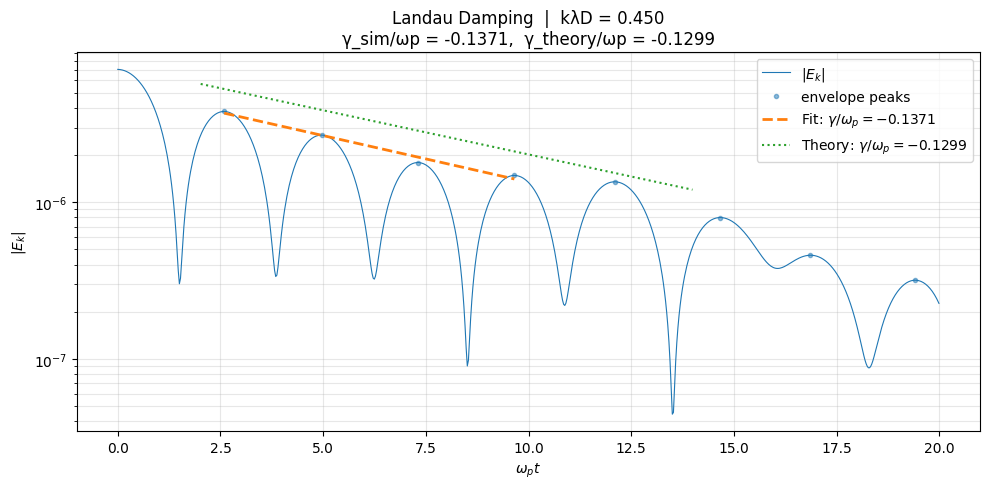

In [25]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Reduce perturbation to stay linear longer (in the IC cell)
# perturbation_amp = 0.01   ← use 0.01 instead of 0.03

# ── 2. Envelope fitting via local maxima ─────────────────────────

time_arr   = np.array(time_steps)
E_mode_arr = np.array(E_mode_amp)
wp = w_p_theory

# Find peaks of the envelope
peak_idx, _ = find_peaks(E_mode_arr, distance=5)   # min 5 steps between peaks

peak_t = time_arr[peak_idx]
peak_E = E_mode_arr[peak_idx]

# Fit window in physical units: ωp·t ∈ [2, 12]
t_norm = peak_t * wp
mask = (t_norm >= 2.0) & (t_norm <= 12.0) & np.isfinite(peak_E) & (peak_E > 0)

fit_t = peak_t[mask]
fit_E = peak_E[mask]

# Log-linear fit on envelope peaks
coeffs    = np.polyfit(fit_t, np.log(fit_E), 1)
gamma_sim = coeffs[0]
A_fit     = np.exp(coeffs[1])

# ── 3. Theory ───────────────────────────────────────────────────
kld = k_wave * lambda_D
gamma_theory = (
    -np.sqrt(np.pi / 8)
    * (wp / kld**3)
    * np.exp(-1.0 / (2 * kld**2) - 1.5)
)

print(f"kλD           = {kld:.4f}")
print(f"γ_sim  / ωp   = {gamma_sim  / wp:.4f}")
print(f"γ_theory / ωp = {gamma_theory / wp:.4f}")

# ── 4. Plot ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.semilogy(time_arr * wp, E_mode_arr, lw=0.8, color='C0', label=r'$|E_k|$')
ax.semilogy(peak_t * wp, peak_E, 'o', ms=3, color='C0', alpha=0.5, label='envelope peaks')

t_fit_line = np.array([fit_t[0], fit_t[-1]])
ax.semilogy(
    t_fit_line * wp,
    A_fit * np.exp(gamma_sim * t_fit_line),
    '--', lw=2, color='C1',
    label=fr'Fit: $\gamma/\omega_p = {gamma_sim/wp:.4f}$'
)

# Theory envelope
t_full = time_arr[(time_arr * wp >= 2) & (time_arr * wp <= 14)]
ax.semilogy(
    t_full * wp,
    A_fit * np.exp(gamma_theory * (t_full - fit_t[0])),
    ':', lw=1.5, color='C2',
    label=fr'Theory: $\gamma/\omega_p = {gamma_theory/wp:.4f}$'
)

ax.set_xlabel(r'$\omega_p t$')
ax.set_ylabel(r'$|E_k|$')
ax.set_title(
    f'Landau Damping  |  kλD = {kld:.3f}\n'
    f'γ_sim/ωp = {gamma_sim/wp:.4f},  γ_theory/ωp = {gamma_theory/wp:.4f}'
)
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig("landau_damping_mode.png", dpi=150)
plt.show()

In [ ]:
from matplotlib import animation
from IPython.display import HTML

stored_t = [np.array(time_steps)[min(i * store_stride, len(time_steps)-1)] * w_p_theory
            for i in range(len(x_his))]

v_ph = 1.0 / target_klD
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xlim(0, 1); ax.set_ylim(-5, 5)
ax.set_xlabel(r'$x/L_x$'); ax.set_ylabel(r'$v_x/v_{th}$')
ax.axhline( v_ph, color='red', lw=1, ls='--', alpha=0.7)
ax.axhline(-v_ph, color='red', lw=1, ls='--', alpha=0.7)
scat  = ax.scatter([], [], s=0.1, alpha=0.5, color='steelblue', rasterized=True)
title = ax.set_title('')

def init():
    scat.set_offsets(np.empty((0, 2)))
    title.set_text('')
    return scat, title

def update(frame):
    scat.set_offsets(np.column_stack([
        np.array(x_his[frame]) / L_x,
        np.array(v_x_his[frame]) / v_th
    ]))
    title.set_text(fr'$\omega_p t = {stored_t[frame]:.1f}$')
    return scat, title


ani = animation.FuncAnimation(fig, update, frames=len(x_his),
                               init_func=init, blit=True, interval=100)
ani.save('Vortex.mp4', writer='ffmpeg', fps=30)